In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H4分子的几何构型（线性排列，等间距）
bond_length = 1.0  # H-H键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
    ('H', (2*bond_length, 0., 0.)),
    ('H', (3*bond_length, 0., 0.))
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -2.09854594 Ha
FCI能量: -2.16638745 Ha


In [2]:
clusters = [(i, j) for i in range(4) for j in range(i+1,4 )]
clusters.extend([(i, j) for i in range(4,8) for j in range(i+1,8 )])
len(clusters)

12

In [3]:
hi = ha.hilbert
g = nk.graph.Graph(edges=clusters)
# 创建采样器
sa = nk.sampler.MetropolisFermionHop(
    hi,
    graph=g,
    n_chains=64,
    spin_symmetric=True,
    sweep_size=hi.size * 4,
    reset_chains=True
)

# 使用Slater模型确保反对称性
ma = nk.models.Jastrow(param_dtype=complex)
vs = nk.vqs.MCState(
    sa,
    ma,
    n_discard_per_chain=100,
    n_samples=2000,
    seed=42
)
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(
    diag_shift=0.01,
    holomorphic=True,
    solver=nk.optimizer.solver.cholesky
)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
jastrow_log = nk.logging.RuntimeLog()
gs.run(300, out=jastrow_log)


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/vqs/mc/mc_state/state.py:300: UserWarning: n_samples=2000 (2000 per device/MPI rank) does not divide n_chains=64, increased to 2048 (2048 per device/MPI rank)
  self.n_samples = n_samples
100%|██████████| 300/300 [00:28<00:00, 10.53it/s, Energy=-2.11167+0.00001j ± 0.00033 [σ²=0.00003, R̂=1.2111]]        


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [4]:
ma = nk.models.RBM(param_dtype=complex,alpha=1)
vs = nk.vqs.MCState(
    sa,
    ma,
    n_discard_per_chain=100,
    n_samples=2000,
    seed=42
)
# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
# 运行优化
RBM_log = nk.logging.RuntimeLog()
gs.run(300, out=RBM_log)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/vqs/mc/mc_state/state.py:300: UserWarning: n_samples=2000 (2000 per device/MPI rank) does not divide n_chains=64, increased to 2048 (2048 per device/MPI rank)
  self.n_samples = n_samples
100%|██████████| 300/300 [01:00<00:00,  4.99it/s, Energy=-2.09833+0.00007j ± 0.00022 [σ²=0.00010, R̂=1.0153]]           


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [7]:
ma = nk.models.RBMModPhase(param_dtype=complex,alpha=1)
vs = nk.vqs.MCState(
    sa,
    ma,
    n_discard_per_chain=100,
    n_samples=2000,
    seed=42
)
# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
# 运行优化
RBMModPhase_log = nk.logging.RuntimeLog()
gs.run(300, out=RBMModPhase_log)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/vqs/mc/mc_state/state.py:300: UserWarning: n_samples=2000 (2000 per device/MPI rank) does not divide n_chains=64, increased to 2048 (2048 per device/MPI rank)
  self.n_samples = n_samples
100%|██████████| 300/300 [01:43<00:00,  2.90it/s, Energy=-2.099e+00-2.207e-05j ± 3.594e-21 [σ²=2.645e-38, R̂=5461.3334]]


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [10]:
y1 = data1["Energy"]["Mean"][-1]
y1

(-2.111671594861096+9.319949108889786e-06j)

In [11]:
y2 = data2["Energy"]["Mean"][-1]
y2

(-2.0983289918380335+6.834232121857242e-05j)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


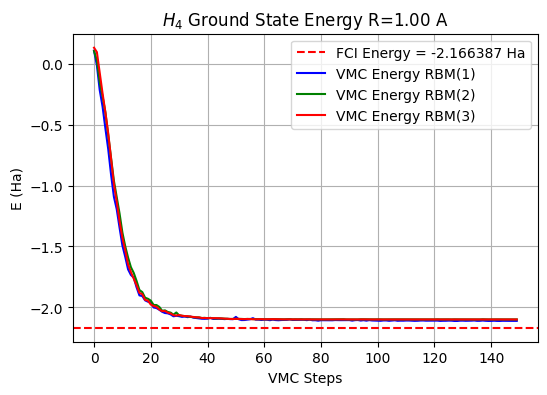


最终VMC能量: -2.11024383+0.00001713j Ha
与FCI能量误差: 0.05614362 Ha


In [12]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量
data1 = jastrow_log
data2 = RBM_log
data3 = RBMModPhase_log

x1 = data1["Energy"]["iters"][:150]
y1 = data1["Energy"]["Mean"][:150]
x2 = data2["Energy"]["iters"][:150]
y2 = data2["Energy"]["Mean"][:150]
x3 = data3["Energy"]["iters"][:150]
y3 = data3["Energy"]["Mean"][:150]

# 绘制能量收敛曲线
plt.figure(figsize=(6, 4))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI Energy = {E_fci:.6f} Ha")
plt.plot(x1, y1, 'b-', label="VMC Energy RBM(1)")
plt.plot(x2, y2, 'g-', label="VMC Energy RBM(2)")
plt.plot(x3, y3, 'r-', label="VMC Energy RBM(3)")
plt.xlabel("VMC Steps")
plt.ylabel("E (Ha)")
plt.title(f"$H_4$ Ground State Energy R={bond_length:.2f} A")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y1[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y1[-1] - E_fci):.8f} Ha")

In [7]:
data1['Energy'].keys()

dict_keys(['iters', 'Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'])